
* Завдання 1 та 2 (читання з файлу), 3 (маніпуляції з даними) та 4 (запис у файл) - обов'язкові (30, 30, 30 та 10 балів відповідно).

* Завдання 5 та 6 (додаткові маніпуляції з значеннями) - вважатимуться бонусними (+5 балів за кожен, максимум 100).


# Вхідні дані

Файли для проєкту:

* [HW_05_Files_Monobank_mcc_codes.csv](https://drive.google.com/file/d/14hNxwm9r3soA-FZi2nDBAHqOVRRXhF-v/view?usp=sharing) - csv файл з додатковою інформацією про MCC коди (треба буде для роботи з транзакціями)
* [HW_05_Files_Monobank_account.json](https://drive.google.com/file/d/1KxPrZn6RFZZCOml1em2j37RmrsDCNZ5X/view?usp=sharing) - json файл з інформацією про акаунти та транзакції

## 1 - Завантажити коди MCC з CSV-файлу

https://github.com/greggles/mcc-codes/blob/main/mcc_codes.csv

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import csv

def load_mcc_codes(filepath: str) -> dict | None:
    """
    Завантажує коди MCC та irs_description з CSV-файлу в словник.

    Аргументи:
    filepath (str): Шлях до CSV-файлу

    Повертає:
    dict: Словник, що відображає коди MCC (як рядки) в описи
    """
    try:
        with open(filepath, mode='r', encoding='utf-8') as f:
          reader = csv.DictReader(f)
          mcc_dict = {}
          for row in reader:
            mcc_dict[row['mcc']] = row['irs_description']

          print("Файл успішно завантажено і оброблено!")
          return mcc_dict
        # десь 6-8 рядків
    except FileNotFoundError:
        print(f"Файл {filepath} не знайдено")
    except KeyError:
        print("Помилка!\nПеревірте наявність колонок 'mcc' та 'irs_description' у файлі!")
    except Exception as e:
        print(f"Сталась непередбачувана помилка [{type(e).__name__}]: {str(e)}")
    return None



mcc_dict = load_mcc_codes("HW_05_Files_Monobank_mcc_codes.csv")

Файл успішно завантажено і оброблено!


In [ ]:
list(mcc_dict.items())[:4]

[('0742', 'Veterinary Services'),
 ('0763', 'Agricultural Cooperative'),
 ('0780', 'Landscaping Services'),
 ('1520', 'General Contractors')]

In [ ]:
len(list(mcc_dict.items()))

981

In [ ]:
mcc_dict['5411']

'Grocery Stores, Supermarkets'

## 2 - Завантажити список транзакцій

In [ ]:
import json

def load_transactions(filepath: str) -> list | None:
    """
    Завантажує список транзакцій з JSON-файлу.

    Аргументи:
    filepath (str): Шлях до JSON-файлу

    Повертає:
    list: Список словників транзакцій
    """
    try:
      with open(filepath, 'r', encoding='utf-8') as file:
        data = json.load(file)
        if isinstance(data, dict):
            return data.get("transactions", None)
        print(f"Файл {filepath} не містить очікуваного типу даних 'словник' (наявний тип даних {type(data).__name__})")
        return None
        # 10-12 рядків
    except FileNotFoundError:
        print(f"Файл {filepath} не знайдено")
    except json.JSONDecodeError as e:
        print(f"Вибачте, не маю змоги декодувати файл json.")
        print(f"При обробці рядка {e.lineno} у стовпчику {e.colno} сталась помилка:")
        print(f"{e.msg}")
    except Exception as e:
        print(f"Сталась непередбачувана помилка [{type(e).__name__}]: {str(e)}")
    return None


transactions = load_transactions("HW_05_Files_Monobank_account.json")

Файл успішно завантажено і оброблено!


In [ ]:
transactions[:1]

[{'id': 'RTQ...',
  'time': 1748976530,
  'description': 'Київське метро',
  'mcc': 4111,
  'originalMcc': 4111,
  'amount': -800,
  'operationAmount': -800,
  'currencyCode': 980,
  'commissionRate': 0,
  'cashbackAmount': 0,
  'balance': 10819,
  'hold': False,
  'receiptId': 'HPCX-...',
  'account': '9Fd...'}]

In [ ]:
len(transactions)

20

### Filter out transfers (e.g., "З чорної картки", MCC 4829)

У цьому підзавданні потрібно виключити з аналізу транзакції, які є внутрішніми переказами між картками (наприклад, з чорної картки на іншу). Такі транзакції не є витратами або покупками, тому вони не мають враховуватись у категоріях витрат.


🔎 Як розпізнати перекази:

* Транзакції з MCC кодом 4829 — це зазвичай грошові перекази, які не стосуються покупок.

* Також можна орієнтуватися на опис транзакції, наприклад: "З чорної картки", "На білу картку" тощо.

In [ ]:
def is_transfer(transaction: dict) -> bool:
    # 1-4 рядка
    return str(transaction['mcc']) == '4829'

In [ ]:
transactions[5]

{'id': 'YU9...',
 'time': 1748688138,
 'description': 'З чорної картки',
 'mcc': 4829,
 'originalMcc': 4829,
 'amount': 60000,
 'operationAmount': 60000,
 'currencyCode': 980,
 'commissionRate': 0,
 'cashbackAmount': 0,
 'balance': 64400,
 'hold': False,
 'account': '9Fd...'}

In [ ]:
is_transfer(transactions[5])

True

In [ ]:
transactions[2]

{'id': 'GjK...',
 'time': 1748691704,
 'description': 'VYDAVNYTSTVO STAROHO LEVA',
 'mcc': 5942,
 'originalMcc': 5942,
 'amount': -50000,
 'operationAmount': -50000,
 'currencyCode': 980,
 'commissionRate': 0,
 'cashbackAmount': 447,
 'balance': 35900,
 'hold': False,
 'receiptId': '9AAX-...',
 'account': '9Fd...'}

In [ ]:
is_transfer(transactions[2])

False

Використай цю функцію, щоб відфільтрувати всі такі транзакції зі списку перед подальшим аналізом.

In [ ]:
filtered_transactions = [t for t in transactions if not is_transfer(t)]

In [ ]:
len(filtered_transactions)

14

## 3 - Загальні витрати за категорією

In [ ]:
def summarize_spending(transactions, mcc_dict):
    """
    Обчислює загальні витрати за категорією на основі кодів MCC.

    Ця функція фільтрує транзакції доходів (сума >= 0),
    зіставляє MCC кожної транзакції з категорією, зрозумілою для людини, за допомогою `mcc_dict`,
    та підсумовує абсолютне значення всіх витрат за категорією.

    Аргументи:
    transactions(list): Список словників транзакцій.
    Кожна транзакція повинна мати поля 'amount' та 'mcc'.

    mcc_dict(dict): Словник, що зіставляє коди MCC (як рядки) з описами категорій.

    Повертає:
    dict: Словник, де ключі – це описи категорій, а значення – загальна сума витрат (як цілі числа).
    """
    summary = {}
    for transaction in transactions:
      amount = transaction.get('amount', 0) * (-0.01)
      mcc_code = transaction.get('mcc', None)
      if amount >= 0 and mcc_code:
        mcc_name = mcc_dict.get(str(mcc_code), mcc_code)
        summary[mcc_name] = summary.get(mcc_name, 0) + amount
    return summary


Для прикладу, тут результата в гривнях:

In [ ]:
summary = summarize_spending(filtered_transactions, mcc_dict)

In [ ]:
summary

{'Commuter Transport, Ferries': 16.0,
 'Grocery Stores, Supermarkets': 242.81,
 'Book Stores': 3250.0,
 'Fast Food Restaurants': 967.0,
 'Taxicabs/Limousines': 915.0}

## 4 - Висновки у файл

In [ ]:
def save_summary_to_json(summary, path):
  try:
    with open(path, 'w', encoding='utf-8') as f:
      json.dump(summary, f, indent=2, ensure_ascii=False)
  except Exception as e:
        print(f"Сталась непередбачувана помилка [{type(e).__name__}]: {str(e)}")
  return None
path = 'book_arsenal_spending.json'
save_summary_to_json(summary, path)

Приклад файлу результату:

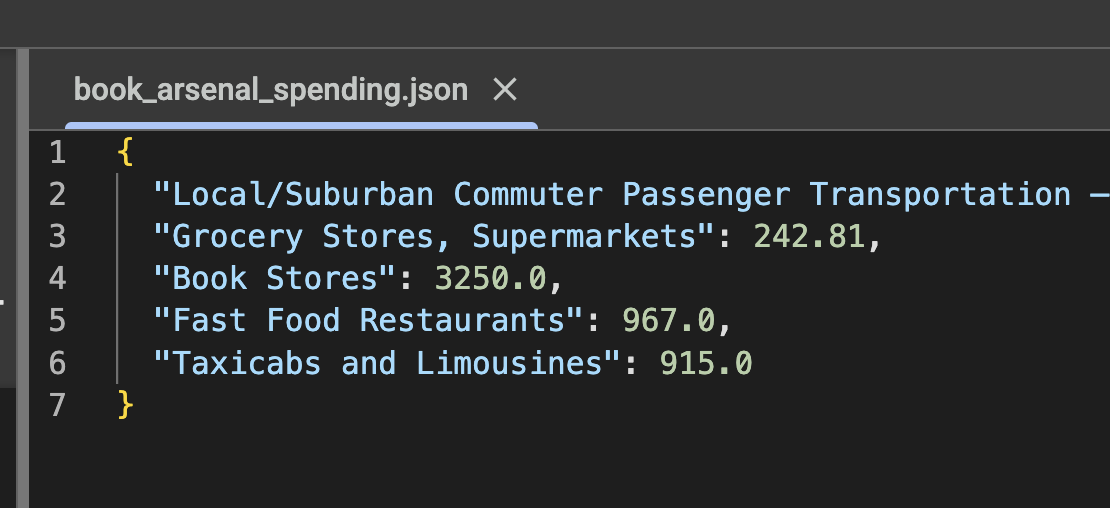

## 5 - Кешбек

In [ ]:
def calculate_total_cashback(transactions):
    """
    Обчислює загальну суму кешбеку, отриману зі списку транзакцій.

    Аргументи:
    transactions(list): Список словників транзакцій. Кожен з них має містити «cashbackAmount».

    Повертає:
    int: Загальна сума кешбеку в найменших грошових одиницях (наприклад, копійках).
    """
    return int(sum([t_c.get('cashbackAmount', 0) for t_c in transactions]))
    # 3-5 рядків

calculate_total_cashback(filtered_transactions)

14567

## 6 - N найдорожчих транзакцій

In [ ]:
def get_top_expenses(transactions, top_n = 3):
    """
    Знаходить N найдорожчих транзакцій.

    Аргументи:
    transactions (list): Список словників транзакцій, кожен з яких містить «суму» та «опис».
    top_n (int): Кількість найвищих витрат, які потрібно повернути (за замовчуванням – 3).

    Повертає:
    list: Список N найвищих транзакцій витрат, відсортованих за найвищими абсолютними витратами.
    """
    lst_trans = []
    for item in transactions:
        amount = item.get('amount', 0) * (-0.01)
        descr = item.get('description', None)
        mcc_code = item.get('mcc', None)
        mcc_name = mcc_dict.get(str(mcc_code), mcc_code)
        lst_trans.append((amount, descr, mcc_name))
    lst_trans.sort(reverse=True, key=lambda x: x[0])
    # 3-5 рядків
    return lst_trans[:top_n]

top_exp = get_top_expenses(filtered_transactions)

print(*(f'\n{item}' for item in top_exp)) # це для листа кортежів

#[(abs(i['amount'] / 100), i['description'], mcc_dict.get(str(i['mcc']))) \
 #for i in top_exp] це для словника


(1000.0, 'FOP LYNNYK', 'Book Stores') 
(782.0, 'FOP TERNOVSKA D. S.', 'Fast Food Restaurants') 
(720.0, 'ABABAGALAMAGA', 'Book Stores')
